# CNN

In [1]:
import numpy as np
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load preprocessed data
X_normalized = np.load("X_normalized.npy")  # Load saved features
label = np.load("label.npy")  # Load saved labels

# Define the neural network class
class cnnmodel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(cnnmodel, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(p=0.5)
        self.fc3 = nn.Linear(128, num_classes)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)
        x = self.fc3(x)
        return self.softmax(x)

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.tensor(X_normalized, dtype=torch.float32)
y_tensor = torch.tensor(label, dtype=torch.long).squeeze()

# Set up dataset and dataloaders
dataset = TensorDataset(X_tensor, y_tensor)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train and evaluate model
num_epochs = 50
learning_rate = 0.001
accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_tensor)):
    print(f"Fold {fold+1}:")
    train_dataset = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
    test_dataset = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    model = cnnmodel(input_size=310, num_classes=len(torch.unique(y_tensor))).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    
    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    accuracy = correct / total *100
    accuracies.append(accuracy)
    print(f"Accuracy: {accuracy:.2f}")
    
    cnn_mean_accuracy = sum(accuracies)/len(accuracies)

print(f"Mean Accuracy: {cnn_mean_accuracy:.2f}%")


Fold 1:
Accuracy: 100.00
Fold 2:
Accuracy: 91.67
Fold 3:
Accuracy: 91.67
Fold 4:
Accuracy: 93.06
Fold 5:
Accuracy: 91.67
Mean Accuracy: 93.61%


# Transformer Model

In [2]:
# Define Transformer-based Model for EEG Data
class EEGTransformer(nn.Module):
    def __init__(self, input_size, num_classes, num_heads=4, num_layers=2, ff_hid_dim=512, dropout=0.1):
        super(EEGTransformer, self).__init__()
        
        self.input_size = input_size
        self.num_classes = num_classes

        # Embedding layer (input projection)
        self.embedding = nn.Linear(input_size, ff_hid_dim)

        # Transformer Encoder Layer
        encoder_layers = nn.TransformerEncoderLayer(d_model=ff_hid_dim, nhead=num_heads, dim_feedforward=ff_hid_dim, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # Output layer for classification
        self.fc_out = nn.Linear(ff_hid_dim, num_classes)

        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Apply input embedding (project the input into the desired feature space)
        x = self.embedding(x)

        # Apply the Transformer Encoder
        x = self.transformer_encoder(x)

        # If the sequence length is 1, the shape will be (batch_size, 1, ff_hid_dim)
        # We want to apply pooling to the time dimension (or sequence dimension)
        # Check if sequence dimension is 1
        if x.size(1) == 1:
            x = x.squeeze(1)  # Remove the sequence dimension if it's 1

        # Apply dropout
        x = self.dropout(x)

        # Final output layer
        x = self.fc_out(x)
        
        return x

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.tensor(X_normalized, dtype=torch.float32)
y_tensor = torch.tensor(label, dtype=torch.long).squeeze()

# Set up dataset and dataloaders
dataset = TensorDataset(X_tensor, y_tensor)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train and evaluate model
num_epochs = 50
learning_rate = 0.001
accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_tensor)):
    print(f"Fold {fold+1}:")
    train_dataset = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
    test_dataset = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Initialize the model
    model = EEGTransformer(input_size=310, num_classes=len(torch.unique(y_tensor))).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    
    # Evaluate the model
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    accuracy = correct / total * 100
    accuracies.append(accuracy)
    print(f"Accuracy: {accuracy:.2f}%")
    
# Calculate and print mean accuracy
tm_mean_accuracy = np.mean(accuracies)
print(f"\nMean Accuracy: {tm_mean_accuracy:.2f}%")


Fold 1:


C:\Users\ASUS\anaconda3\code\lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Accuracy: 93.06%
Fold 2:
Accuracy: 80.56%
Fold 3:
Accuracy: 87.50%
Fold 4:
Accuracy: 90.28%
Fold 5:
Accuracy: 88.89%

Mean Accuracy: 88.06%


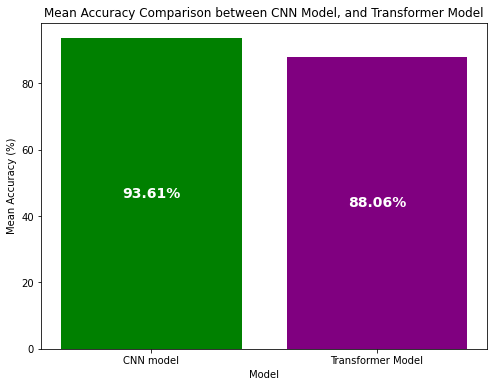

In [3]:
import matplotlib.pyplot as plt

cnn_mean_accuracy = cnn_mean_accuracy  # Replace with actual accuracy
transformer_mean_accuracy = tm_mean_accuracy  # The mean accuracy for your Transformer model

# Bar plot for comparison
plt.figure(figsize=(8, 6))
models = ['CNN model', 'Transformer Model']  # Add Transformer Model
mean_accuracies = [cnn_mean_accuracy, transformer_mean_accuracy]
colors = ['green', 'purple']  # Add color for the Transformer

bars = plt.bar(models, mean_accuracies, color=colors)

# Display accuracy values in the middle of the bars
for bar, accuracy in zip(bars, mean_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
             f"{accuracy:.2f}%", ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Labels and title
plt.xlabel('Model')
plt.ylabel('Mean Accuracy (%)')
plt.title('Mean Accuracy Comparison between CNN Model, and Transformer Model')

# Display the plot
plt.show()


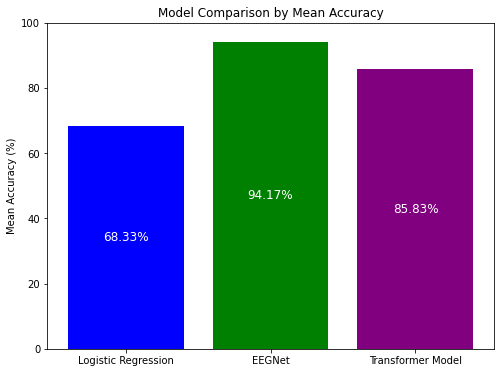

In [4]:
import matplotlib.pyplot as plt

# Define mean accuracies (replace with actual values)
logistic_mean_accuracy = 68.33  # Example value
cm_mean_accuracy = 93.61        # Example value for EEGNet
transformer_mean_accuracy = 88.06  # Example value for Transformer

# Bar plot setup
plt.figure(figsize=(8, 6))  # Adjusted figure size
models = ['Logistic Regression', 'EEGNet', 'Transformer Model']
mean_accuracies = [logistic_mean_accuracy, cm_mean_accuracy, transformer_mean_accuracy]  # Fixed variable name
colors = ['blue', 'green', 'purple']

bars = plt.bar(models, mean_accuracies, color=colors)

# Display accuracy values on the bars
for bar, accuracy in zip(bars, mean_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{accuracy:.2f}%",  # Added % sign for clarity
        ha='center',
        va='center',
        fontsize=12,
        color='white'
    )

plt.ylabel('Mean Accuracy (%)')
plt.title('Model Comparison by Mean Accuracy')
plt.ylim(0, 100)  # Adjusted for percentage values
plt.show()